<a href="https://colab.research.google.com/github/rodwol/hidden_markov_models/blob/main/Hidden_Markov_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.3 MB/s eta 0:00:00


import the necessary libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from hmmlearn import hmm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# download the dataset
path = kagglehub.dataset_download("rodasgoniche/data-new")

print("Dataset path:", path)
print("Files in root directory:")
print(os.listdir(path))


100%|██████████| 4.34M/4.34M [00:00<00:00, 11.5MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1
Files in root directory:
['Still_6-2026-03-05_22-06-58', 'Still_10-2026-03-05_22-08-07', 'Walking_6-2026-03-05_21-43-18', 'Jumping_6-2026-03-05_21-03-27', 'Jumping_7-2026-03-05_21-03-55', 'Still_4-2026-03-05_22-06-24', 'Still_5-2026-03-05_22-06-41', 'Walking_2-2026-03-05_21-42-10', 'Still_8-2026-03-05_22-07-34', 'Walking_1-2026-03-05_21-41-53', 'Still_7-2026-03-05_22-07-14', 'Walking_9-2026-03-05_21-44-14', 'Standing_3-2026-03-05_21-11-34', 'Standing_10-2026-03-05_21-14-43', 'Walking_5-2026-03-05_21-43-00', 'Jumping_4-2026-03-05_21-02-37', 'Jumping_2-2026-03-05_21-01-46', 'Still_1-2026-03-05_22-05-32', 'Standing_4-2026-03-05_21-11-49', 'Walking_3-2026-03-05_21-42-25', 'Still_2-2026-03-05_22-05-50', 'Walking_4-2026-03-05_21-42-44', 'Still_9-2026-03-05_22-07-50', 'Still_3-2026-03-05_22-06-08', 'Standing_5-2026-03-05_21-12-13', 'Standing_1-2026-03-05_21-10-56', 'Standing_8-2026-03-05_21-13-53', 'Standing_9-2026

In [4]:
path = "/root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1"
all_data = []

for folder in os.listdir(path):
  folder_path = os.path.join(path, folder)
  if os.path.isdir(folder_path):
    # extract activity from folder name
    activity = folder.split("_")[0].lower()

    for file in os.listdir(folder_path):
      file_path = os.path.join(folder_path, file)
      try:
        df = pd.read_csv(file_path)
        # skip empty dataframes
        if df.empty:
          print(f"Skipping empty dataframe in {file_path}")
          continue

        df["activity"] = activity
        df["sensor"] = file.replace(".csv", "")
        df["session"] = folder
        all_data.append(df)

      except pd.errors.EmptyDataError:
        print(f"Skipping empty dataframe in {file_path}")

dataset = pd.concat(all_data, ignore_index=True)
print("Final dataset shape:", dataset.shape)
dataset.head()

Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_6-2026-03-05_22-06-58/AccelerometerUncalibrated.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_6-2026-03-05_22-06-58/Annotation.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_10-2026-03-05_22-08-07/AccelerometerUncalibrated.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_10-2026-03-05_22-08-07/Annotation.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Walking_6-2026-03-05_21-43-18/AccelerometerUncalibrated.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Walking_6-2026-03-05_21-43-18/Annotation.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Jumping_6-2026-03-05_21-03-27/Accelerome

,time,seconds_elapsed,z,y,x,activity,sensor,session,version,device name,recording epoch time,recording time,recording timezone,platform,appVersion,device id,sensors,sampleRateMs,standardisation,platform version
0,1.772748e+18,0.234328,9.768343,-0.095768,0.050278,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.772748e+18,0.250288,9.749189,-0.086191,0.045490,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.772748e+18,0.266249,9.753978,-0.098162,0.052672,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.772748e+18,0.282210,9.753978,-0.081403,0.057461,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.772748e+18,0.298201,9.730036,-0.102951,0.059855,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


timestamp cleaning

In [5]:
# remove duplicated, focusing on the 'time' column to ensure unique timestamps
dataset = dataset.drop_duplicates(subset=["session","time"])
# sort by time
dataset = dataset.sort_values(["session","time"])
dataset = dataset.dropna(axis=1, how="all")

# convert timestamp to datetime
dataset["time"] = pd.to_datetime(dataset["time"])

dataset = dataset
for session in dataset["session"].unique():
  session_data = dataset[dataset["session"] == session]
  assert np.all(np.diff(session_data["time"].astype("int64")) > 0)


print("Timestamp cleaning done.")
print(dataset.columns)

Timestamp cleaning done.
Index(['time', 'seconds_elapsed', 'z', 'y', 'x', 'activity', 'sensor',
       'session', 'version', 'device name', 'recording epoch time',
       'recording time', 'recording timezone', 'platform', 'appVersion',
       'device id', 'sensors', 'sampleRateMs', 'standardisation',
       'platform version'],
      dtype='object')


In [6]:
dataset = dataset[[
    "time",
    "seconds_elapsed",
    "x",
    "y",
    "z",
    "activity",
    "session",
    "sensor"
]]

In [7]:
dataset = dataset.dropna()

In [8]:
print(dataset.isnull().sum())

time               0
seconds_elapsed    0
x                  0
y                  0
z                  0
activity           0
session            0
sensor             0
dtype: int64


In [9]:
print(dataset["activity"].value_counts())

activity
still       29654
standing    28777
walking     28649
jumping     26532
Name: count, dtype: int64


In [10]:
print(dataset[["x","y","z"]].describe())

                   x              y              z
count  113612.000000  113612.000000  113612.000000
mean        0.455257       2.064348       0.982737
std         1.611157       5.017675       3.310222
min       -14.871499     -16.839993     -20.140133
25%        -0.024435      -0.083797      -0.279165
50%         0.003665       0.000000      -0.001222
75%         0.475253       1.207681       0.503353
max        27.818230      43.198582      20.061016


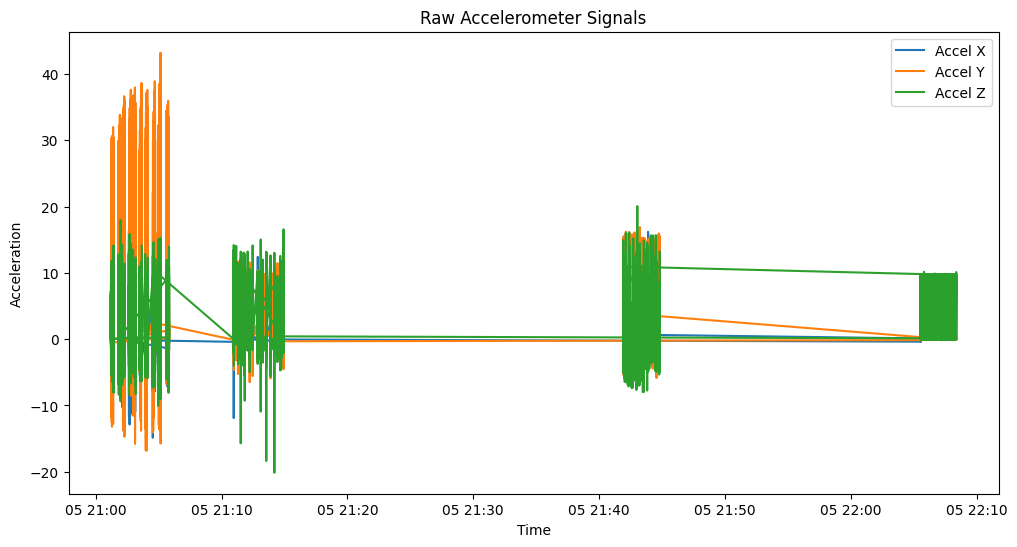

In [11]:
plt.figure(figsize=(12,6))

plt.plot(dataset["time"], dataset["x"], label="Accel X")
plt.plot(dataset["time"], dataset["y"], label="Accel Y")
plt.plot(dataset["time"], dataset["z"], label="Accel Z")

plt.title("Raw Accelerometer Signals")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()
plt.show()

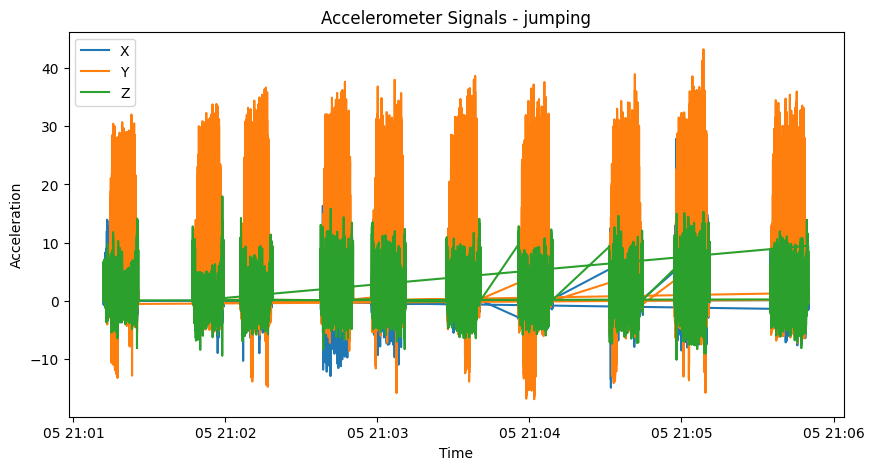

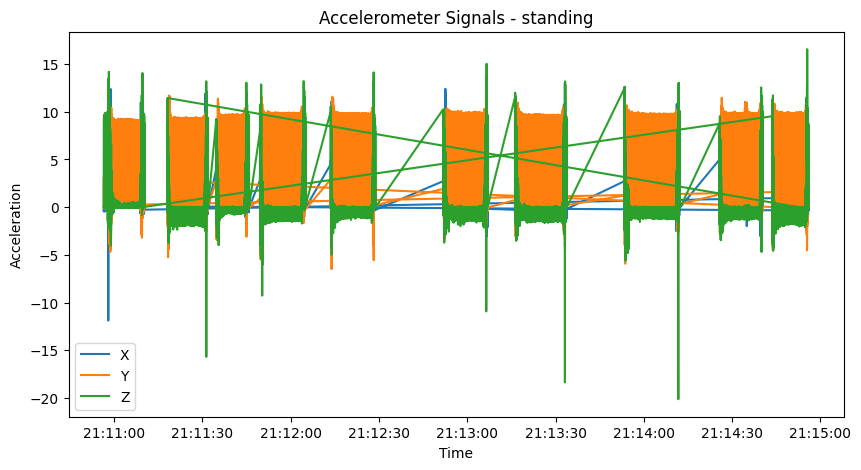

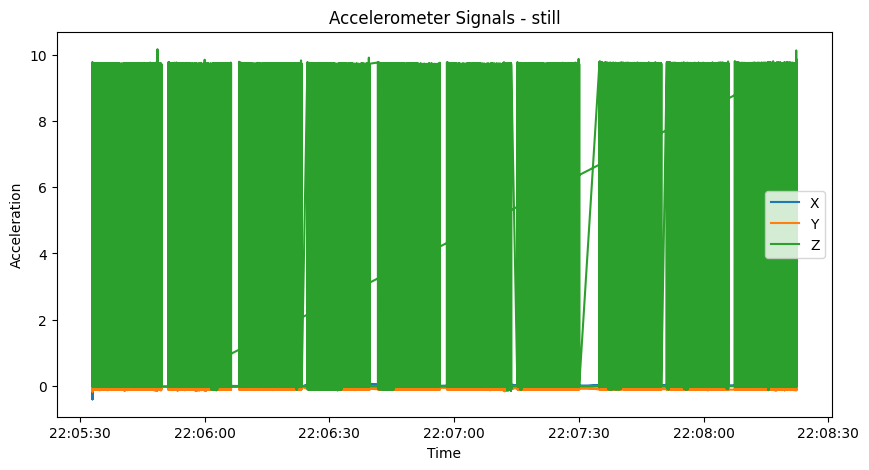

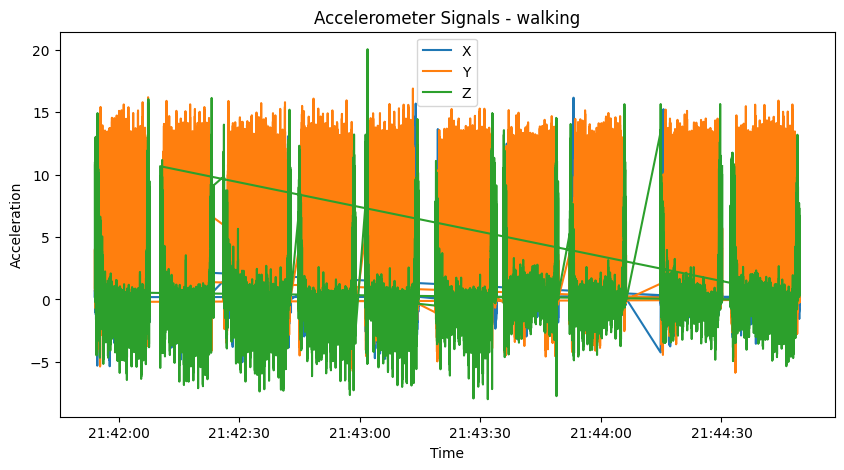

In [12]:
activities = dataset["activity"].unique()

for activity in activities:
    data = dataset[dataset["activity"] == activity]

    plt.figure(figsize=(10,5))
    plt.plot(data["time"], data["x"], label="X")
    plt.plot(data["time"], data["y"], label="Y")
    plt.plot(data["time"], data["z"], label="Z")

    plt.title(f"Accelerometer Signals - {activity}")
    plt.xlabel("Time")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.show()

compute sampling rate

In [13]:
dt = np.diff(dataset["time"].astype("int64") / 1e9)
sampling_rate = 1/np.mean(dt)

print("Estimated sampling rate:", sampling_rate)

Estimated sampling rate: 43.727125157806604


#**Resampling**
The accelerometer data was recorded using a smartphone sensor. Because different devices may record data at slightly different frequencies, we estimated the sampling rate by computing the time difference between consecutive timestamps. The average sampling rate was approximately X Hz.
To ensure consistency in the dataset, the signals were resampled to 50 Hz, meaning one sample every 20 ms.

In [14]:
dataset = dataset.set_index("time")

# resample to 50Hz (20ms interval)
dataset_resampled = dataset.groupby(["session","sensor"])[["x", "y", "z"]].resample("20ms").mean()
dataset_resampled = dataset_resampled.interpolate()

dataset_resampled.reset_index(inplace=True)
dataset_resampled.head()

,session,sensor,time,x,y,z
0,Jumping_1-2026-03-05_21-01-11,Accelerometer,2026-03-05 21:01:11.980,-0.106335,-0.040114,-0.108611
1,Jumping_1-2026-03-05_21-01-11,Accelerometer,2026-03-05 21:01:12.000,-0.060490,-0.012023,0.014507
2,Jumping_1-2026-03-05_21-01-11,Accelerometer,2026-03-05 21:01:12.020,0.039805,0.026529,0.011224
3,Jumping_1-2026-03-05_21-01-11,Accelerometer,2026-03-05 21:01:12.040,0.077699,0.115350,-0.122824
4,Jumping_1-2026-03-05_21-01-11,Accelerometer,2026-03-05 21:01:12.060,-0.078846,0.116791,-0.114249


calclate and plot the magnitude of acceleration from 3-axis accelerometer data

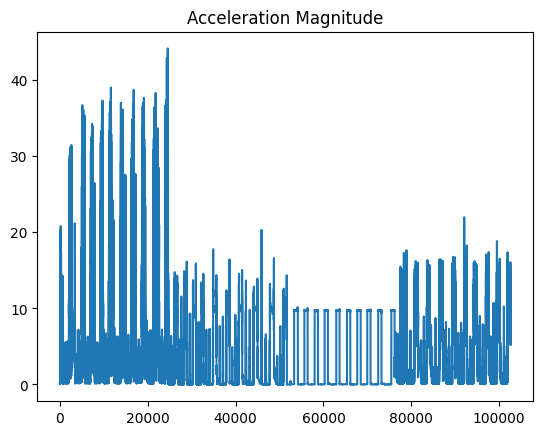

In [15]:
dataset_resampled["acc_mag"] = np.sqrt(
    dataset_resampled["x"]**2+
    dataset_resampled["y"]**2+
    dataset_resampled["z"]**2
 )
magnitude = dataset_resampled["acc_mag"]

plt.plot(magnitude)
plt.title("Acceleration Magnitude")
plt.show()

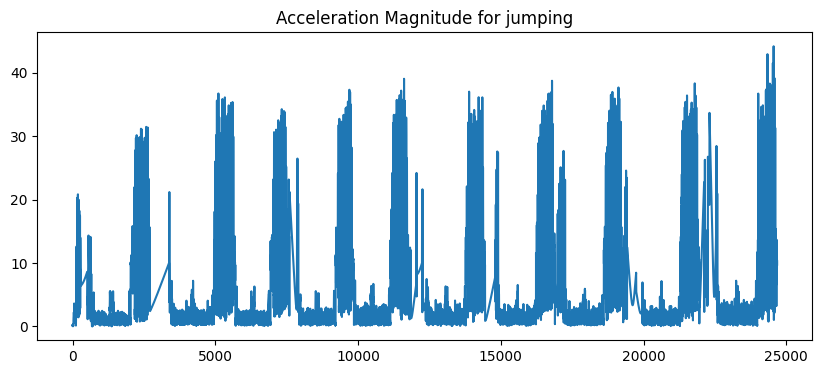

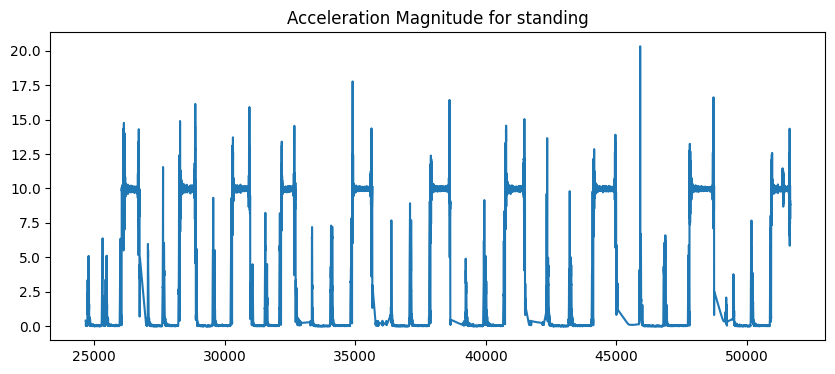

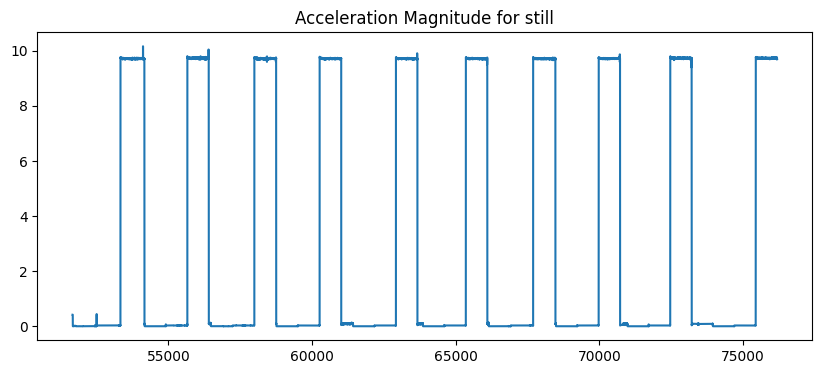

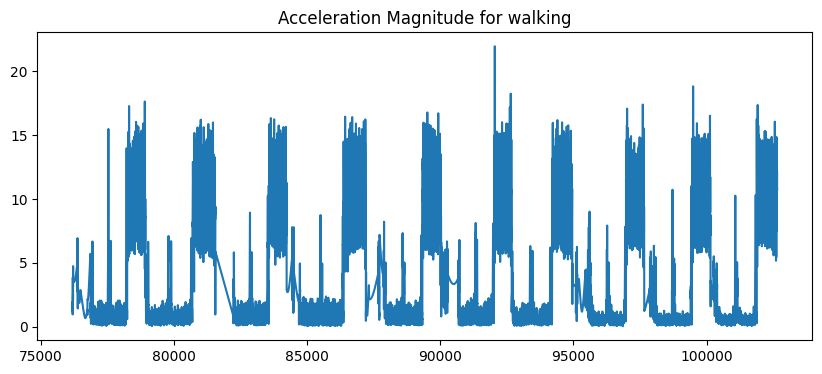

In [16]:
session_activity_map = dataset.drop_duplicates(subset=['session'])[['session', 'activity']].set_index('session')['activity']
dataset_resampled['activity'] = dataset_resampled['session'].map(session_activity_map)

# Now, iterate through activities using dataset_resampled
for activity in dataset_resampled["activity"].unique():

    # Filter dataset_resampled for the current activity
    subset_resampled = dataset_resampled[dataset_resampled["activity"] == activity]

    plt.figure(figsize=(10,4))
    # Plot the 'acc_mag' which is the computed magnitude
    plt.plot(subset_resampled["acc_mag"])
    plt.title(f"Acceleration Magnitude for {activity}") # More descriptive title
    plt.show()

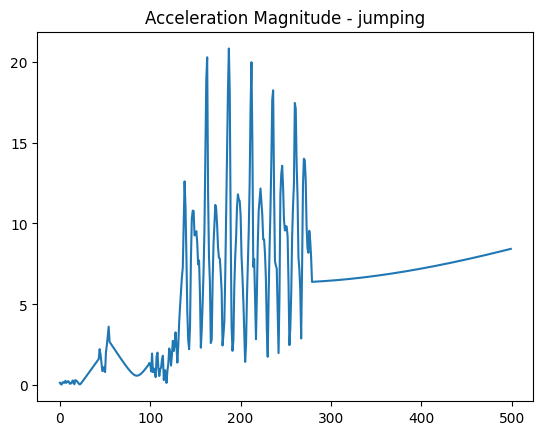

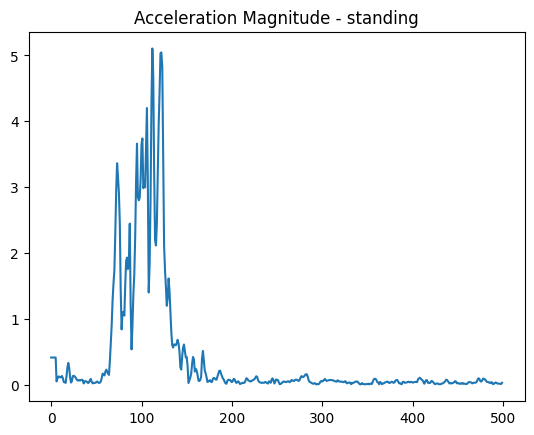

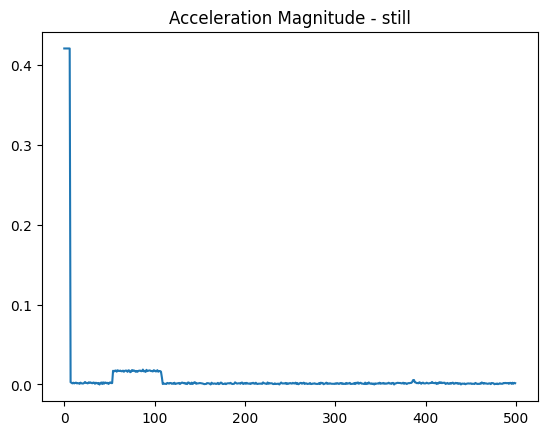

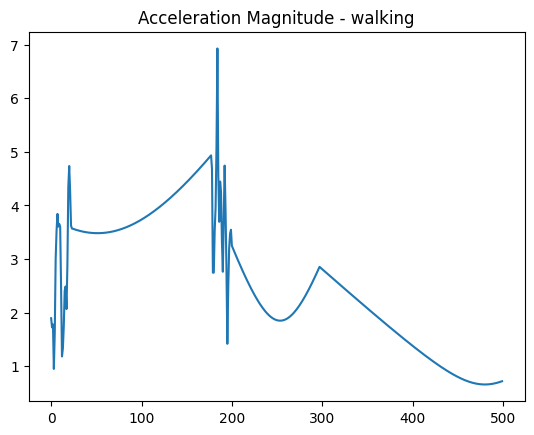

In [17]:
for activity in dataset_resampled["activity"].unique():
    subset = dataset_resampled[dataset_resampled["activity"] == activity]
    plt.plot(subset["acc_mag"].values[:500])
    plt.title(f"Acceleration Magnitude - {activity}")
    plt.show()

applying low-pass filter to smooth the acceleration magnitude by removing high-frequency noise while preserving the meaningful movement patterns.

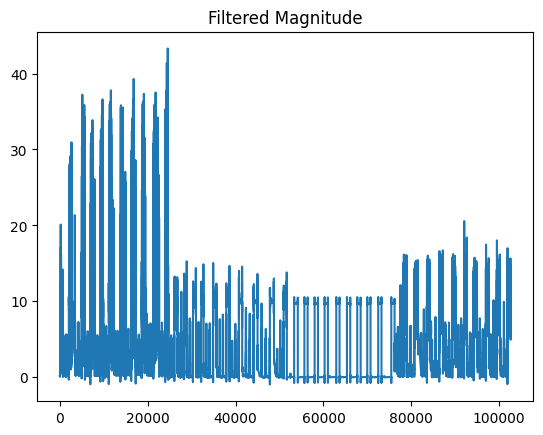

In [18]:
def lowpass_filter(signal, cutoff=10, fs=50, order=4):
  nyq = 0.5 * fs
  normal_cutoff = cutoff / nyq
  b, a = butter(order, normal_cutoff, btype='low')
  return filtfilt(b, a, signal)

magnitude_filtered = lowpass_filter(magnitude, cutoff=10, fs=50)

plt.plot(magnitude_filtered)
plt.title("Filtered Magnitude")
plt.show()

# Windowing
To extract meaningful features from the continuous sensor signals, the data was divided into fixed-length time windows.
Given the sampling rate of 50 Hz, a window size of 2 seconds (100 samples) was chosen.
This window length captures several motion cycles during walking while still allowing quick detection of activity transitions.

In [19]:
window_size = 100
step_size = 50

features = []

axes = ["x", "y", "z", "acc_mag"]

for start in range(0, len(dataset_resampled) - window_size, step_size):
    window = dataset_resampled.iloc[start:start+window_size]

    window_activity = window["activity"].mode()[0]
    if (window["activity"] == window_activity).mean() < 0.8:
      continue

    feature_row = {}

    for axis in axes:
      signal = window[axis].values

      # time-domain fetures
      feature_row[f"{axis}_mean"] = signal.mean()
      feature_row[f"{axis}_std"] = signal.std()
      feature_row[f"{axis}_max"] = signal.max()
      feature_row[f"{axis}_min"] = signal.min()
      feature_row[f"{axis}_range"] = signal.max() - signal.min()
      feature_row[f"{axis}_median"] = np.median(signal)
      feature_row[f"{axis}_iqr"] = np.quantile(signal, 0.75) - np.quantile(signal, 0.25)
      feature_row[f"{axis}_rms"] = np.sqrt(np.mean(signal**2))
      feature_row[f"{axis}_sma"] = np.sum(np.abs(signal)) / len(signal)

      fft_vals = np.fft.rfft(signal)
      fft_freq = np.fft.rfftfreq(len(signal), d=1/50)  # 50 Hz sampling
      feature_row[f"{axis}_dominant_freq"] = fft_freq[np.argmax(np.abs(fft_vals))]
      feature_row[f"{axis}_spectral_energy"] = np.sum(np.abs(fft_vals)**2)

    feature_row["activity"] = window_activity
    feature_row["session"] = window["session"].iloc[0]  # optional, useful for sequence split

    features.append(feature_row)

features_df = pd.DataFrame(features)
features_df.head()

,x_mean,x_std,x_max,x_min,x_range,x_median,x_iqr,x_rms,x_sma,x_dominant_freq,...,acc_mag_min,acc_mag_range,acc_mag_median,acc_mag_iqr,acc_mag_rms,acc_mag_sma,acc_mag_dominant_freq,acc_mag_spectral_energy,activity,session
0,-0.335746,0.954655,1.318046,-2.461370,3.779417,-0.095102,1.217613,1.011974,0.737574,0.5,...,0.049134,3.574457,0.867613,1.099649,1.278609,1.016032,0.0,13335.888700,jumping,Jumping_1-2026-03-05_21-01-11
1,-0.693286,0.922029,1.242447,-2.461370,3.703817,-0.617720,1.582661,1.153596,0.913495,0.0,...,0.145766,12.459093,1.563335,1.591613,3.689914,2.504942,0.0,99454.042180,jumping,Jumping_1-2026-03-05_21-01-11
2,-0.576871,1.431047,2.386397,-6.241717,8.628114,-0.412406,1.672716,1.542944,1.115049,0.0,...,0.145766,20.673146,5.732312,7.472305,7.883371,6.204574,0.0,503252.638036,jumping,Jumping_1-2026-03-05_21-01-11
3,-0.704991,1.700462,3.727513,-6.241717,9.969230,-0.799440,2.047980,1.840811,1.466363,0.0,...,1.443481,19.375431,8.460942,5.676289,9.970161,8.891865,0.0,892354.460291,jumping,Jumping_1-2026-03-05_21-01-11
4,-0.391464,1.866210,4.601316,-4.700495,9.301811,-0.492025,2.715998,1.906826,1.565546,4.0,...,1.443481,18.527253,7.740840,4.454133,9.410291,8.592247,0.0,811915.323986,jumping,Jumping_1-2026-03-05_21-01-11


In [20]:
acc_mag = window["acc_mag"]
feature_row = {
    "mean": acc_mag.mean(),
    "std": acc_mag.std(),
    "max": acc_mag.max(),
    "activity": window["activity"].mode()[0]
}
list(feature_row.items())[:5]

[('mean', np.float64(10.28139484858059)),
 ('std', 2.451954961578423),
 ('max', 16.057909763213882),
 ('activity', 'walking')]

normalizing features

In [21]:
train_sessions = []
test_sessions = []

for activity in features_df["activity"].unique():

    activity_sessions = features_df[features_df["activity"] == activity]["session"].unique()

    split_index = int(0.8 * len(activity_sessions))

    train_sessions.extend(activity_sessions[:split_index])
    test_sessions.extend(activity_sessions[split_index:])

train_data = features_df[features_df["session"].isin(train_sessions)]
test_data = features_df[features_df["session"].isin(test_sessions)]

X_train = train_data.drop(["activity","session"], axis=1)
y_train = train_data["activity"]

X_test = test_data.drop(["activity","session"], axis=1)
y_test = test_data["activity"]



In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model training

In [23]:
model = hmm.GaussianHMM(
    n_components=4,               # hidden states
    covariance_type="full",
    n_iter=1000,
    tol=1e-4,
    random_state=42
  )

model.fit(X_train)

GaussianHMM(covariance_type='full', n_components=4, n_iter=1000,
            random_state=42, tol=0.0001)

In [24]:
hidden_states = model.predict(X_test)

In [25]:
from scipy.stats import mode

state_map = {}
for state in np.unique(hidden_states):
    mask = hidden_states == state
    most_common_label = y_test[mask].mode()[0]
    state_map[state] = most_common_label

predictions = [state_map[s] for s in hidden_states]

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Quick check (keep)
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

# Detailed per-activity metrics (new)
report = classification_report(y_test, predictions, output_dict=True)
for activity in y_test.unique():
    sens = report[activity]["recall"]           # Sensitivity
    prec = report[activity]["precision"]       # Precision
    f1 = report[activity]["f1-score"]
    print(f"{activity}: Sensitivity={sens:.2f}, Precision={prec:.2f}, F1={f1:.2f}")

Accuracy: 0.6061224489795919
Confusion Matrix:
 [[ 58   5   0  43]
 [ 17  45  53  17]
 [  3   0 144   7]
 [ 23  25   0  50]]
jumping: Sensitivity=0.55, Precision=0.57, F1=0.56
standing: Sensitivity=0.34, Precision=0.60, F1=0.43
still: Sensitivity=0.94, Precision=0.73, F1=0.82
walking: Sensitivity=0.51, Precision=0.43, F1=0.47


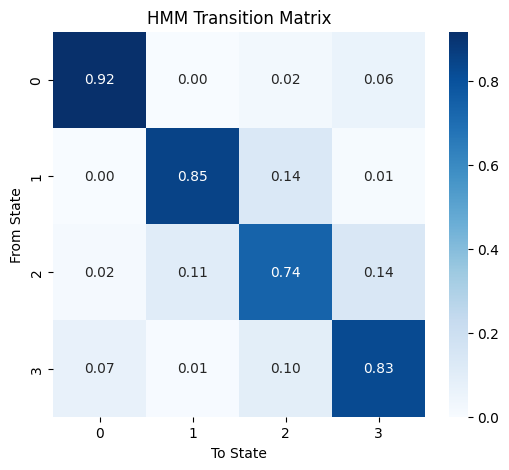

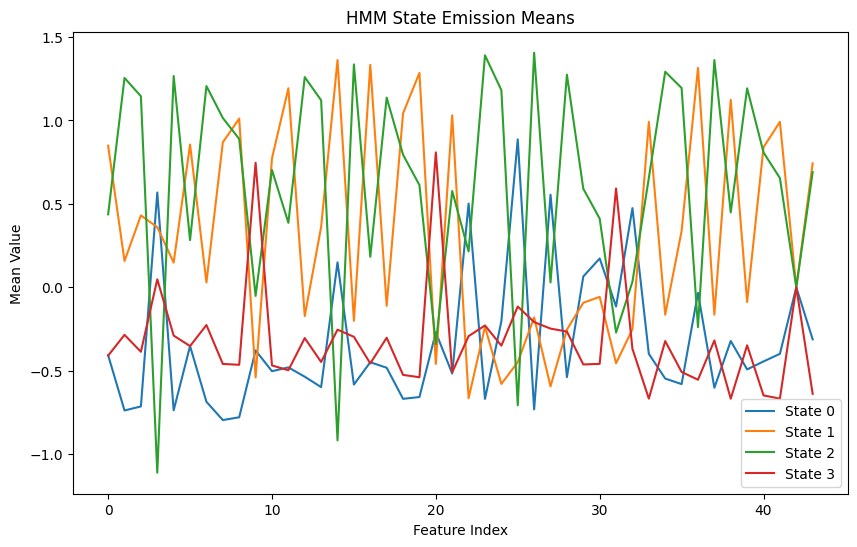

In [28]:
import seaborn as sns

# Transition matrix
plt.figure(figsize=(6,5))
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
plt.title("HMM Transition Matrix")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

# Emission probabilities approximated by Gaussian means per state
plt.figure(figsize=(10,6))
for i in range(model.n_components):
    plt.plot(model.means_[i], label=f"State {i}")
plt.title("HMM State Emission Means")
plt.xlabel("Feature Index")
plt.ylabel("Mean Value")
plt.legend()
plt.show()